In [1]:
library(readxl)
library(dplyr)
library(tidyr)
library(stringr)
library(psych)      # PCA / fator
library(scales)
library(lavaan)
library(semTools)
library(tidyverse)

Warning message:
"pacote 'readxl' foi compilado no R versão 4.5.3"

Anexando pacote: 'dplyr'


Os seguintes objetos são mascarados por 'package:stats':

    filter, lag


Os seguintes objetos são mascarados por 'package:base':

    intersect, setdiff, setequal, union


Warning message:
"pacote 'psych' foi compilado no R versão 4.5.3"

Anexando pacote: 'scales'


Os seguintes objetos são mascarados por 'package:psych':

    alpha, rescale


This is lavaan 0.6-21
lavaan is FREE software! Please report any bugs.


Anexando pacote: 'lavaan'


O seguinte objeto é mascarado por 'package:psych':

    cor2cov


 

###############################################################################

This is semTools 0.5-7

All users of R (or SEM) are invited to submit functions or ideas for functions.

###############################################################################


Anexando pacote: 'semTools'


Os seguintes objetos são mascarados por 'package:psych':

    reliability, skew


Warnin

In [2]:
install.packages("janitor")
library(janitor)

Instalando pacote em 'C:/Users/Maxwell/AppData/Local/R/win-library/4.5'
(como 'lib' não foi especificado)



pacote 'janitor' desempacotado com sucesso e somas MD5 verificadas

Os pacotes binários baixados estão em
	C:\Users\Maxwell\AppData\Local\Temp\RtmpYd6JpQ\downloaded_packages


Warning message:
"pacote 'janitor' foi compilado no R versão 4.5.3"

Anexando pacote: 'janitor'


Os seguintes objetos são mascarados por 'package:stats':

    chisq.test, fisher.test




In [40]:
knowledge <- read_excel("Knowledge.xlsx") 
ete <- read_excel("ETE.xlsx") 
job <- read_excel("Job_Zones.xlsx")

In [41]:
knowledge <- clean_names(knowledge) 
ete <- clean_names(ete) 
job <- clean_names(job)

In [47]:
knowledge_wide <- knowledge %>%
  filter(scale_id == "LV") %>%
  select(o_net_soc_code, element_name, data_value) %>%
  pivot_wider(names_from = element_name, values_from = data_value)

In [48]:
ete_numeric <- ete %>%
  group_by(o_net_soc_code, element_name) %>%
  mutate(weight = data_value / sum(data_value)) %>%
  summarise(score = sum(as.numeric(category) * weight, na.rm = TRUE)) %>%
  pivot_wider(names_from = element_name,
              values_from = score)

`summarise()` has grouped output by 'o_net_soc_code'. You can override using the `.groups` argument.


In [49]:
job_zone <- job %>%
  select(o_net_soc_code, job_zone)

In [54]:
data_clean <- data_full %>%
  select(-o_net_soc_code) %>%
  select(where(~ sd(., na.rm = TRUE) > 0))

In [55]:
apply(data_clean, 2, sd, na.rm = TRUE)

Administration and Management                Administrative 
                    0.9056732                     1.1838748 
     Economics and Accounting           Sales and Marketing 
                    1.0490908                     1.1748109 
Customer and Personal Service Personnel and Human Resources 
                    1.2264739                     1.0349542 
    Production and Processing               Food Production 
                    1.1525446                     0.8609755 
    Computers and Electronics    Engineering and Technology 
                    1.2222705                     1.5043561 
                       Design     Building and Construction 
                    1.4403401                     1.4311384 
                   Mechanical                   Mathematics 
                    1.6175790                     1.1120830 
                      Physics                     Chemistry 
                    1.3483562                     1.3470967 
                      Biology                    Psychology 
                    1.5364273                     1.3862778 
   Sociology and Anthropology                     Geography 
                    1.2710222                     1.2371411 
       Medicine and Dentistry        Therapy and Counseling 
                    1.4290162                     1.4325346 
       Education and Training              English Language 
                    1.1270781                     0.9500039 
             Foreign Language                     Fine Arts 
                    0.7251891                     0.9879597 
       History and Archeology       Philosophy and Theology 
                    0.9703440                     1.1104435 
   Public Safety and Security            Law and Government 
                    0.9860721                     1.0684837 
           Telecommunications      Communications and Media 
                    0.8584304                     0.9961642 
               Transportation  On-Site or In-Plant Training 
                    1.0197205                     0.8716924 
          On-the-Job Training       Related Work Experience 
                    0.9295164                     1.6213663 
  Required Level of Education                      job_zone 
                    2.6233059                     1.1154415

In [57]:
data_scaled <- scale(data_clean)

pca_model <- prcomp(data_scaled)
summary(pca_model)

Importance of components:
                          PC1    PC2     PC3     PC4    PC5    PC6     PC7
Standard deviation     3.3167 2.6549 1.74206 1.57582 1.4999 1.3004 1.16536
Proportion of Variance 0.2895 0.1855 0.07986 0.06535 0.0592 0.0445 0.03574
Cumulative Proportion  0.2895 0.4750 0.55485 0.62019 0.6794 0.7239 0.75963
                           PC8     PC9    PC10    PC11    PC12    PC13    PC14
Standard deviation     1.04937 0.91101 0.85992 0.75320 0.71996 0.71462 0.68350
Proportion of Variance 0.02898 0.02184 0.01946 0.01493 0.01364 0.01344 0.01229
Cumulative Proportion  0.78861 0.81045 0.82991 0.84484 0.85848 0.87192 0.88421
                          PC15    PC16    PC17    PC18    PC19    PC20    PC21
Standard deviation     0.64827 0.62298 0.58851 0.54822 0.53823 0.51241 0.47222
Proportion of Variance 0.01106 0.01021 0.00911 0.00791 0.00762 0.00691 0.00587
Cumulative Proportion  0.89527 0.90549 0.91460 0.92251 0.93013 0.93704 0.94291
                          PC22    PC23    

In [58]:
pca_model <- prcomp(data_clean, scale. = TRUE)

In [61]:
data_full$index_pca <- pca_model$x[,1]

In [62]:
data_full$index_norm <- (data_full$index_pca - min(data_full$index_pca)) /
                        (max(data_full$index_pca) - min(data_full$index_pca))

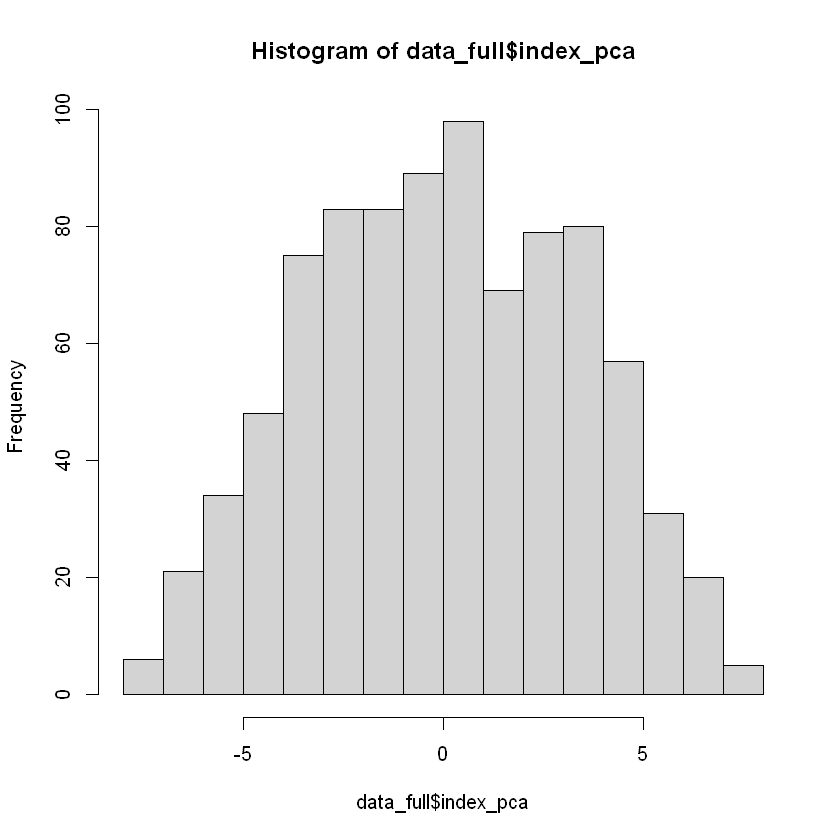

In [63]:
hist(data_full$index_pca)

In [64]:
cor(data_full$index_pca, data_full$job_zone)

[1] -0.7938335

In [65]:
pca_model$rotation[,1]

Administration and Management                Administrative 
                 -0.202567637                  -0.213212287 
     Economics and Accounting           Sales and Marketing 
                 -0.155192349                  -0.124739255 
Customer and Personal Service Personnel and Human Resources 
                 -0.176608709                  -0.227493439 
    Production and Processing               Food Production 
                  0.065672363                  -0.007373934 
    Computers and Electronics    Engineering and Technology 
                 -0.196766803                  -0.022970267 
                       Design     Building and Construction 
                 -0.022137533                   0.027208055 
                   Mechanical                   Mathematics 
                  0.096288142                  -0.135742735 
                      Physics                     Chemistry 
                 -0.033146928                  -0.043413312 
                      Biology                    Psychology 
                 -0.152888106                  -0.216343193 
   Sociology and Anthropology                     Geography 
                 -0.239176322                  -0.169494241 
       Medicine and Dentistry        Therapy and Counseling 
                 -0.130397186                  -0.185377099 
       Education and Training              English Language 
                 -0.244125009                  -0.258984128 
             Foreign Language                     Fine Arts 
                 -0.168884528                  -0.079455129 
       History and Archeology       Philosophy and Theology 
                 -0.185963106                  -0.212440677 
   Public Safety and Security            Law and Government 
                 -0.075408201                  -0.210716927 
           Telecommunications      Communications and Media 
                 -0.119409559                  -0.236273846 
               Transportation  On-Site or In-Plant Training 
                 -0.005488400                  -0.044527281 
          On-the-Job Training       Related Work Experience 
                 -0.041987840                  -0.166055857 
  Required Level of Education                      job_zone 
                 -0.240601736                  -0.239341835

In [66]:
index_2d <- pca_model$x[,1] * 0.2895 +
            pca_model$x[,2] * 0.1855

In [68]:
data_full$qualificacao_bruta <- -pca_model$x[,1]

In [69]:
data_full$qualificacao <- (data_full$qualificacao_bruta - min(data_full$qualificacao_bruta)) /
                          (max(data_full$qualificacao_bruta) - min(data_full$qualificacao_bruta))

In [70]:
ranking <- data_full %>%
  arrange(desc(qualificacao)) %>%
  mutate(rank = row_number())

In [74]:
final_dataset <- ranking %>%
  select(o_net_soc_code, qualificacao, rank)

In [75]:
final_dataset

o_net_soc_code,qualificacao,rank
<chr>,<dbl>,<int>
25-1067.00,1.0000000,1
29-1229.04,0.9995428,2
29-1229.03,0.9924987,3
25-1061.00,0.9910469,4
19-3091.00,0.9781540,5
25-1113.00,0.9686918,6
25-1122.00,0.9622146,7
29-1141.02,0.9591792,8
29-1216.00,0.9566727,9
